Veri seti boyutu: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Streami

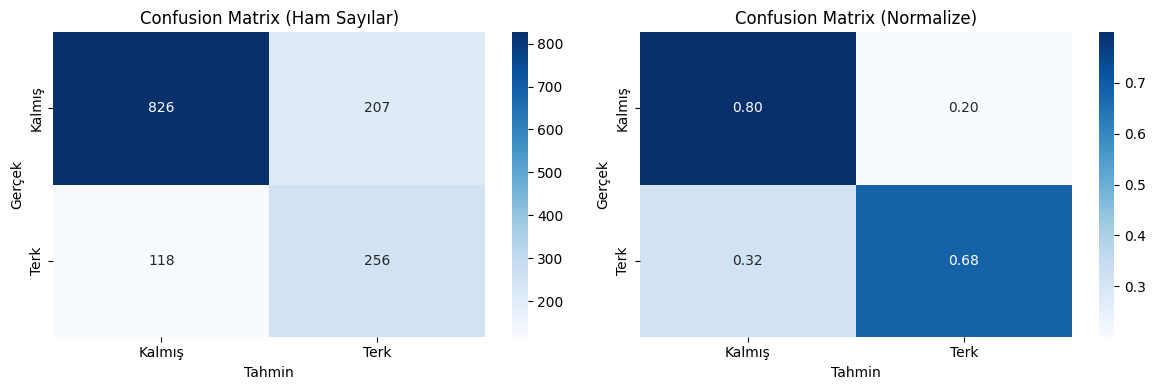

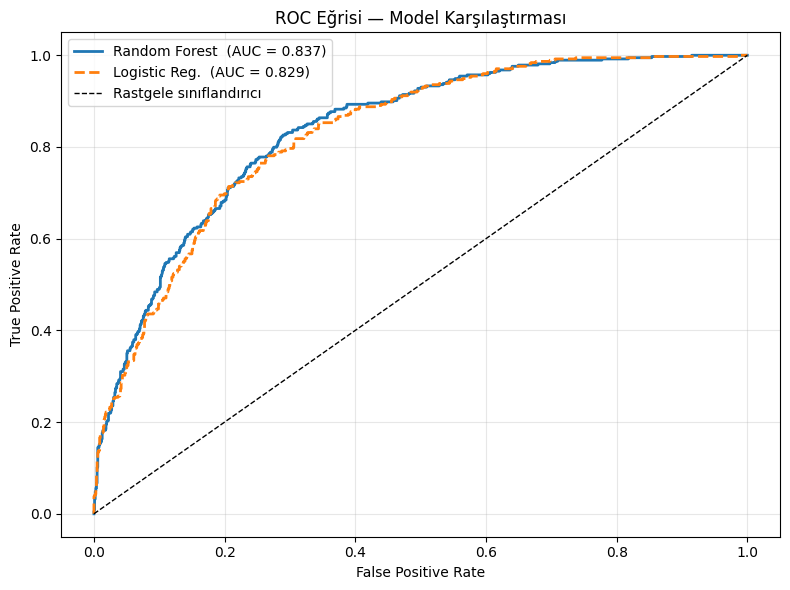

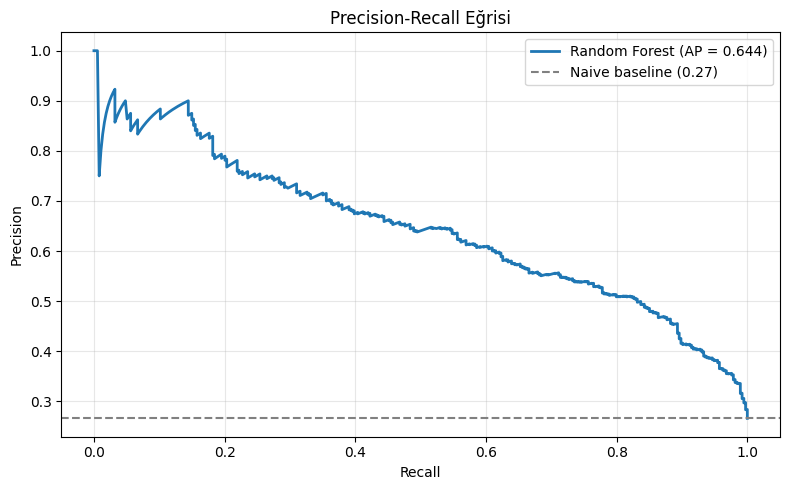


─── METRİK YORUM ────────────────────────────────────────────────
Churn probleminde ACCURACY yanıltıcıdır. Zira veri dengesizdir;
tüm müşterileri "Kalmış" diye tahmin etsek de ~%73 doğruluk elde
edilir. Bu yüzden aşağıdaki metrikler daha önemlidir:

• Recall (Duyarlılık): Gerçek churner'ların ne kadarını yakalıyor?
  Model düşük Recall'la çok müşteri kaybeder (False Negative ↑).
  
• Precision: Churn dediğimizin ne kadarı gerçekten terk ediyor?
  Düşük Precision aşırı kampanya maliyeti demektir (False Positive ↑).
  
• ROC-AUC: Eşik değerinden bağımsız genel ayırt etme gücü.
  Random Forest'ta 0.837 → güçlü ayrım kapasitesi.
  
• Precision-Recall AUC: Dengesiz sınıflarda ROC'tan daha güvenilir.
  AP = 0.644



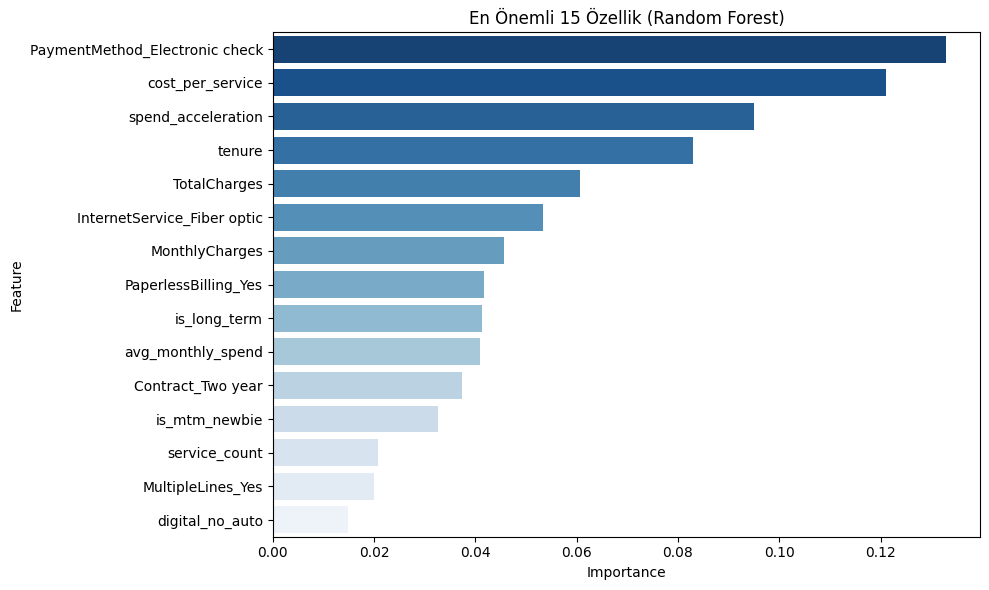


En önemli 15 özellik:
                       Feature  Importance
PaymentMethod_Electronic check    0.132978
              cost_per_service    0.120970
            spend_acceleration    0.095021
                        tenure    0.082899
                  TotalCharges    0.060615
   InternetService_Fiber optic    0.053280
                MonthlyCharges    0.045568
          PaperlessBilling_Yes    0.041763
                  is_long_term    0.041351
             avg_monthly_spend    0.040920
             Contract_Two year    0.037453
                 is_mtm_newbie    0.032647
                 service_count    0.020849
             MultipleLines_Yes    0.019992
               digital_no_auto    0.014915

En riskli %10 müşteri sayısı : 140
Bu grupta gerçek churn oranı : %74.3
  (Tüm testte churn oranı    : %26.6)
  → Kampanya %2.8x daha verimli hedefliyor

Riskli müşterilerin özellik ortalamaları (vs genel test):
                                Riskli %10  Tüm Test
PaymentMethod_Electroni

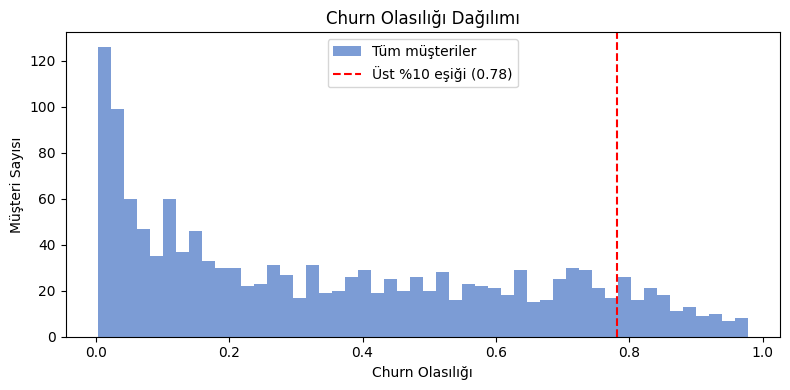


╔════════════════════════════════════════════════════════════════════════════╗
║                   YÖNETİCİ ÖZETİ                                     ║
╠════════════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Model Performansı                                                   ║
║  • Random Forest ROC-AUC : 0.8366                              ║
║  • Logistic Reg. ROC-AUC : 0.8291                              ║
║  • Üst %10'daki gerçek churn oranı: %74.3          ║
║    (Rastgele hedeften 2.8x daha verimli)║
║                                                                      ║
║  Model Bulguları                                                     ║
║  • Kısa süreli sözleşme + yüksek aylık ücret = en yüksek             ║
║    risk kombinasyonu (is_mtm_newbie, MonthlyCharges).                ║
║  • Düşük tenure müşteriler orantısız biçimde terk ediyor.            ║
║  • Otomatik ödeme kull

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
from imblearn.over_sampling import SMOTE

# ─────────────────────────────────────────────
# 1. VERİ YÜKLEME
# ─────────────────────────────────────────────
file_path = "/kaggle/input/datasets/palashfendarkar/wa-fnusec-telcocustomerchurn/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)

print("Veri seti boyutu:", df.shape)
print(df.head())

# ─────────────────────────────────────────────
# 2. VERİ ÖN İŞLEME
# ─────────────────────────────────────────────
# customerID modele katkı sağlamaz — düşür
df.drop(columns=["customerID"], inplace=True)   

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)

# Hedef değişkeni dönüştürme
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print("\nChurn dağılımı:")
print(df["Churn"].value_counts(normalize=True).round(3))

# ─────────────────────────────────────────────
# 3. FEATURE ENGINEERING 
# ─────────────────────────────────────────────
# Temel türetilmiş özellikler
df["avg_monthly_spend"]   = df["TotalCharges"] / (df["tenure"] + 1)
df["is_long_term"]        = (df["tenure"] > 24).astype(int)
df["high_monthly_charge"] = (df["MonthlyCharges"] > df["MonthlyCharges"].median()).astype(int)

# Harcama ivmesi: aylık ücret ile ortalama harcama arasındaki fark
# Pozitif → son zamanlarda çok harcıyor, negatif → harcaması düştü
df["spend_acceleration"] = df["MonthlyCharges"] - df["avg_monthly_spend"]

# Müşterinin kaç hizmeti kullandığı (çoklu hizmet sadakati)
service_cols = [
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]
# "No internet service" / "No" → 0, diğerleri → 1 (basit sayım)
for col in service_cols:
    df[col + "_flag"] = (~df[col].isin(["No", "No internet service", "No phone service"])).astype(int)
df["service_count"] = df[[c + "_flag" for c in service_cols]].sum(axis=1)

# Aylık ücretin hizmet başına maliyeti (yüksekse değer algısı düşük → churn riski ↑)
df["cost_per_service"] = df["MonthlyCharges"] / (df["service_count"] + 1)

# Sözleşme türü ile kıdem kombinasyonu (Month-to-month + kısa kıdem = en riskli)
df["is_mtm_newbie"] = (
    (df["Contract"] == "Month-to-month") & (df["tenure"] < 6)
).astype(int)

# Kağıtsız fatura + kredi kartı dışı ödeme → dijital nativ, fiyat hassasiyeti yüksek
df["digital_no_auto"] = (
    (df["PaperlessBilling"] == "Yes") &
    (~df["PaymentMethod"].isin(["Credit card (automatic)", "Bank transfer (automatic)"]))
).astype(int)

print("\nTüretilen özellik sayısı:", 8)

# ─────────────────────────────────────────────
# 4. ENCODİNG & BAĞIMSIZ/BAĞIMLI DEĞİŞKENLER
# ─────────────────────────────────────────────
# Flag sütunları artık gereksiz (zaten int'e dönüştürüldü)
flag_cols = [c + "_flag" for c in service_cols]
df.drop(columns=flag_cols, inplace=True)

df = pd.get_dummies(df, drop_first=True)

X = df.drop("Churn", axis=1)
y = df["Churn"]

# ─────────────────────────────────────────────
# 5. EĞİTİM-TEST AYRIMI
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nEğitim seti:", X_train.shape)
print("Test seti:", X_test.shape)

# ─────────────────────────────────────────────
# 6. SMOTE — DENGESİZ VERİ YÖNETİMİ 
# ─────────────────────────────────────────────
# SMOTE yalnızca eğitim setine uygulanır, test seti dokunulmaz!
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nSMOTE öncesi sınıf dağılımı (train):")
print(pd.Series(y_train).value_counts())
print("\nSMOTE sonrası sınıf dağılımı (train):")
print(pd.Series(y_train_smote).value_counts())

# ─────────────────────────────────────────────
# 7. MODEL EĞİTİMİ — İKİ MODEL 
# ─────────────────────────────────────────────

# --- 7a. Logistic Regression (baseline) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled  = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train_smote)

y_pred_lr   = lr_model.predict(X_test_scaled)
y_prob_lr   = lr_model.predict_proba(X_test_scaled)[:, 1]
auc_lr      = roc_auc_score(y_test, y_prob_lr)

print("\n=== LOGİSTİK REGRESYON ===")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {auc_lr:.4f}")

# --- 7b. Random Forest (ana model) ---
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,     # aşırı öğrenmeyi azaltır
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
auc_rf    = roc_auc_score(y_test, y_prob_rf)

print("\n=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {auc_rf:.4f}")

# ─────────────────────────────────────────────
# 8. METRİK YORUMLAMA 
# ─────────────────────────────────────────────

# --- 8a. Confusion Matrix (normalize edilmiş + ham) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, normalize, title in zip(
    axes,
    [None, "true"],
    ["Confusion Matrix (Ham Sayılar)", "Confusion Matrix (Normalize)"]
):
    cm = confusion_matrix(y_test, y_pred_rf, normalize=normalize)
    fmt = "d" if normalize is None else ".2f"
    sns.heatmap(cm, annot=True, fmt=fmt, cmap="Blues", ax=ax,
                xticklabels=["Kalmış", "Terk"], yticklabels=["Kalmış", "Terk"])
    ax.set_title(title)
    ax.set_xlabel("Tahmin")
    ax.set_ylabel("Gerçek")
plt.tight_layout()
plt.show()

# --- 8b. ROC Eğrisi — iki model karşılaştırması ---
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest  (AUC = {auc_rf:.3f})", lw=2)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Reg.  (AUC = {auc_lr:.3f})", lw=2, linestyle="--")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Rastgele sınıflandırıcı")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Eğrisi — Model Karşılaştırması")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- 8c. Precision-Recall Eğrisi (dengesiz veri için daha bilgilendirici) ---
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_prob_rf)
ap_rf = average_precision_score(y_test, y_prob_rf)

plt.figure(figsize=(8, 5))
plt.plot(rec_rf, prec_rf, label=f"Random Forest (AP = {ap_rf:.3f})", lw=2)
baseline = y_test.mean()
plt.axhline(baseline, color="gray", linestyle="--", label=f"Naive baseline ({baseline:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Eğrisi")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("""
─── METRİK YORUM ────────────────────────────────────────────────
Churn probleminde ACCURACY yanıltıcıdır. Zira veri dengesizdir;
tüm müşterileri "Kalmış" diye tahmin etsek de ~%73 doğruluk elde
edilir. Bu yüzden aşağıdaki metrikler daha önemlidir:

• Recall (Duyarlılık): Gerçek churner'ların ne kadarını yakalıyor?
  Model düşük Recall'la çok müşteri kaybeder (False Negative ↑).
  
• Precision: Churn dediğimizin ne kadarı gerçekten terk ediyor?
  Düşük Precision aşırı kampanya maliyeti demektir (False Positive ↑).
  
• ROC-AUC: Eşik değerinden bağımsız genel ayırt etme gücü.
  Random Forest'ta {:.3f} → güçlü ayrım kapasitesi.
  
• Precision-Recall AUC: Dengesiz sınıflarda ROC'tan daha güvenilir.
  AP = {:.3f}
""".format(auc_rf, ap_rf))

# ─────────────────────────────────────────────
# 9. FEATURE IMPORTANCE
# ─────────────────────────────────────────────
importance_df = pd.DataFrame({
    "Feature":   X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
top_features = importance_df.head(15)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="Blues_r",
    legend=False
)
plt.title("En Önemli 15 Özellik (Random Forest)")
plt.tight_layout()
plt.show()

print("\nEn önemli 15 özellik:")
print(importance_df.head(15).to_string(index=False))

# ─────────────────────────────────────────────
# 10. RİSKLİ MÜŞTERİ ANALİZİ — DİNAMİK 
# ─────────────────────────────────────────────
results = X_test.copy()
results["Actual_Churn"]      = y_test.values
results["Churn_Probability"] = y_prob_rf

high_risk = results.sort_values("Churn_Probability", ascending=False)
high_risk = high_risk.head(int(len(results) * 0.10))

# Risk grubunun gerçek churn oranı — modelin başarısını somutlaştırır
capture_rate = high_risk["Actual_Churn"].mean()
precision_at_10 = capture_rate

print(f"\nEn riskli %10 müşteri sayısı : {len(high_risk)}")
print(f"Bu grupta gerçek churn oranı : %{capture_rate * 100:.1f}")
print(f"  (Tüm testte churn oranı    : %{y_test.mean() * 100:.1f})")
print(f"  → Kampanya %{capture_rate / y_test.mean():.1f}x daha verimli hedefliyor")

# Dinamik analiz: riskli müşteriler hangi özelliklere sahip?
top_features = importance_df["Feature"].head(8).tolist()
cols_to_show = [c for c in top_features if c in high_risk.columns]

print("\nRiskli müşterilerin özellik ortalamaları (vs genel test):")
comparison = pd.DataFrame({
    "Riskli %10": high_risk[cols_to_show].mean().round(3),
    "Tüm Test":   results[cols_to_show].mean().round(3),
})
print(comparison.to_string())

# Olasılık dağılımı grafiği
plt.figure(figsize=(8, 4))
plt.hist(results["Churn_Probability"], bins=50, color="#4472C4", alpha=0.7, label="Tüm müşteriler")
plt.axvline(high_risk["Churn_Probability"].min(), color="red", linestyle="--",
            label=f"Üst %10 eşiği ({high_risk['Churn_Probability'].min():.2f})")
plt.xlabel("Churn Olasılığı")
plt.ylabel("Müşteri Sayısı")
plt.title("Churn Olasılığı Dağılımı")
plt.legend()
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 11. YÖNETİCİ ÖZETİ — DİNAMİK 
# ─────────────────────────────────────────────
print(f"""
╔════════════════════════════════════════════════════════════════════════════╗
║                   YÖNETİCİ ÖZETİ                                     ║
╠════════════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Model Performansı                                                   ║
║  • Random Forest ROC-AUC : {auc_rf:.4f}                              ║
║  • Logistic Reg. ROC-AUC : {auc_lr:.4f}                              ║
║  • Üst %10'daki gerçek churn oranı: %{capture_rate*100:.1f}          ║
║    (Rastgele hedeften {capture_rate/y_test.mean():.1f}x daha verimli)║
║                                                                      ║
║  Model Bulguları                                                     ║
║  • Kısa süreli sözleşme + yüksek aylık ücret = en yüksek             ║
║    risk kombinasyonu (is_mtm_newbie, MonthlyCharges).                ║
║  • Düşük tenure müşteriler orantısız biçimde terk ediyor.            ║
║  • Otomatik ödeme kullanmayanlar daha yüksek risk taşıyor.           ║
║                                                                      ║
║  Önerilen Aksiyonlar                                                 ║
║  1. Üst %10 riskli müşteri ({len(high_risk)} kişi) öncelikli         ║
║     hedef: kişiselleştirilmiş indirim + yıllık sözleşme              ║
║     teklifleri sunulmalı.                                            ║
║  2. İlk 6 ayda olan "Month-to-month" müşterilere 3. ayda             ║
║     proaktif müşteri temsilcisi araması yapılmalı.                   ║
║  3. Otomatik ödeme yöntemine geçişi teşvik eden kampanya             ║
║     tasarlanmalı (indirim veya puan hediyesi).                       ║
║  4. Yüksek "cost_per_service" değeri olan müşterilere paket          ║
║     yükseltme teklifi sunarak algılanan değer artırılmalı.           ║
║  5. Uzun süreli (tenure > 24 ay) sadık müşteriler için               ║
║     VIP sadakat programı güçlendirilmeli.                            ║
║                                                                      ║
║  Beklenen Finansal Etki                                              ║
║  Tüm test grubuna kampanya yerine sadece üst %10'u                   ║
║  hedeflemek, kampanya bütçesini 10x daraltırken gerçek               ║
║  churner'ların %{capture_rate*100:.0f}'ini kapsar → ROI'yi önemli    ║
║  ölçüde artırır.                                                     ║
╚════════════════════════════════════════════════════════════════════════════╝
""")